### Extracción de los datos desde NEON y versionado inicial

Configuración de rutas y variables de entorno

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Resolver la raíz del proyecto de forma robusta
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Cargar variables de entorno desde el .env de la raíz
ENV_PATH = PROJECT_ROOT / ".env"
load_dotenv(dotenv_path=ENV_PATH)

DATABASE_URL = os.getenv("DATABASE_URL")
if not DATABASE_URL:
    raise ValueError("No se encontró DATABASE_URL en el archivo .env")

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Users\Usuario\OneDrive\Documentos\Marcos\Proyectos\end2end-ml-deploy


Extracción directa desde Neon (SQLAlchemy)

In [2]:
import pandas as pd
from sqlalchemy import create_engine

# Compatibilidad con dialectos de SQLAlchemy
db_url = DATABASE_URL
if db_url.startswith("postgres://"):
    db_url = db_url.replace("postgres://", "postgresql://", 1)

# Crear conexión y extraer datos
engine = create_engine(db_url)
query = "SELECT * FROM loan_data"

df = pd.read_sql(query, con=engine)
print(f"Registros extraídos de Neon: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head(3)

Registros extraídos de Neon: 4269 filas, 13 columnas


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


División Train / Test

In [3]:
from sklearn.model_selection import train_test_split

# Identificamos la columna target
TARGET_COL = "loan_status"

# Split 75% Train, 25% Test estratificado
train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df[TARGET_COL]
)

print(f"Tamaño Train: {train_df.shape[0]} registros")
print(f"Tamaño Test:  {test_df.shape[0]} registros")
print("\nDistribución del target en Train:")
print(train_df[TARGET_COL].value_counts(normalize=True))

Tamaño Train: 3201 registros
Tamaño Test:  1068 registros

Distribución del target en Train:
loan_status
Approved    0.622306
Rejected    0.377694
Name: proportion, dtype: float64


Guardado en formato Parquet

In [4]:
# Definir rutas de destino
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Guardar Snapshot crudo
df.to_parquet(RAW_DIR / "loans_raw.parquet", index=False)

# Guardar Train y Test
train_df.to_parquet(PROCESSED_DIR / "train.parquet", index=False)
test_df.to_parquet(PROCESSED_DIR / "test.parquet", index=False)

print("Archivos Parquet guardados con éxito en data/raw/ y data/processed/")

Archivos Parquet guardados con éxito en data/raw/ y data/processed/


### EDA

#### Análisis descriptivo

In [5]:
import pandas as pd

# Leer directamente el dataset de entrenamiento persistido
train_df = pd.read_parquet(PROCESSED_DIR / "train.parquet")
print(f"Dataset de entrenamiento cargado: {train_df.shape[0]} filas, {train_df.shape[1]} columnas")

Dataset de entrenamiento cargado: 3201 filas, 13 columnas


In [6]:
train_df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1779,2,Graduate,Yes,1600000,4700000,12,582,1500000,1300000,5200000,1000000,Approved
1,486,4,Graduate,No,1600000,4900000,8,685,3200000,2000000,3800000,1500000,Approved
2,1092,4,Not Graduate,Yes,600000,2100000,6,558,1300000,1000000,2200000,300000,Approved


Cantidad de valores nulos, valores faltantes y errores

In [7]:
# Calcular cantidad y porcentaje de valores nulos por columna
missing_data = pd.DataFrame({
    'nulos': train_df.isnull().sum(),
    'porcentaje': (train_df.isnull().sum() / len(train_df)) * 100
})

# Filtrar solo columnas con datos faltantes y ordenar de mayor a menor
missing_data = missing_data[missing_data['nulos'] > 0].sort_values(by='porcentaje', ascending=False)

if missing_data.empty:
    print("No hay valores faltantes en ninguna columna.")
else:
    print(missing_data.round(2))

# Analizar columnas numéricas con valores iguales a cero
num_cols = train_df.select_dtypes(include=['number']).columns

print()

zero_counts = (train_df[num_cols] == 0).sum()
zero_data = pd.DataFrame({
    'ceros': zero_counts,
    'porcentaje': (zero_counts / len(train_df)) * 100
})

# Filtrar solo las que tienen al menos un cero
zero_data = zero_data[zero_data['ceros'] > 0].sort_values(by='porcentaje', ascending=False)

if zero_data.empty:
    print("No hay valores iguales a cero en variables numéricas.")
else:
    print(zero_data.round(2))

import numpy as np

print()

# Definir patrones típicos de error en hojas de cálculo y sistemas heredados
EXCEL_ERRORS = [
    "#VALUE!", "#DIV/0!", "#N/A", "#REF!", "#NAME?", "#NUM!", "#NULL!",
    "?", "null", "none", "nan", "na", ""
]

# Buscar errores de texto en columnas tipo object/string
text_cols = train_df.select_dtypes(include=['object', 'string']).columns
text_error_counts = {}

for col in text_cols:
    matches = train_df[col].astype(str).str.strip().str.lower().isin([e.lower() for e in EXCEL_ERRORS])
    count = matches.sum()
    if count > 0:
        text_error_counts[col] = count

# Buscar infinitos (np.inf, -np.inf) en columnas numéricas
num_cols = train_df.select_dtypes(include=['number']).columns
inf_counts = np.isinf(train_df[num_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]

# Reporte
print("Errores de texto / hojas de cálculo")
if text_error_counts:
    for col, count in text_error_counts.items():
        print(f"Columna '{col}': {count} registros con cadenas corruptas")
else:
    print("No se encontraron cadenas corruptas de Excel ni artefactos de texto.")

print("\n Valores infinitos (inf / -inf) ")
if not inf_counts.empty:
    print(inf_counts)
else:
    print("No se encontraron valores infinitos en columnas numéricas.")

No hay valores faltantes en ninguna columna.

                          ceros  porcentaje
no_of_dependents            547       17.09
commercial_assets_value      79        2.47
residential_assets_value     36        1.12
bank_asset_value              6        0.19

Errores de texto / hojas de cálculo
No se encontraron cadenas corruptas de Excel ni artefactos de texto.

 Valores infinitos (inf / -inf) 
No se encontraron valores infinitos en columnas numéricas.


Tipos de variables y rangos de valores

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   3201 non-null   int64 
 1   no_of_dependents          3201 non-null   int64 
 2   education                 3201 non-null   object
 3   self_employed             3201 non-null   object
 4   income_annum              3201 non-null   int64 
 5   loan_amount               3201 non-null   int64 
 6   loan_term                 3201 non-null   int64 
 7   cibil_score               3201 non-null   int64 
 8   residential_assets_value  3201 non-null   int64 
 9   commercial_assets_value   3201 non-null   int64 
 10  luxury_assets_value       3201 non-null   int64 
 11  bank_asset_value          3201 non-null   int64 
 12  loan_status               3201 non-null   object
dtypes: int64(10), object(3)
memory usage: 325.2+ KB


In [9]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,3201.0,NaN,NaN,NaN,2135.196813,1238.159625,1.0,1048.0,2147.0,3212.0,4269.0
no_of_dependents,3201.0,NaN,NaN,NaN,2.480475,1.698991,0.0,1.0,2.0,4.0,5.0
education,3201,2,Graduate,1615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,3201,2,Yes,1603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,3201.0,NaN,NaN,NaN,5020087.472665,2803992.598483,200000.0,2600000.0,5000000.0,7400000.0,9900000.0
loan_amount,3201.0,NaN,NaN,NaN,14976632.302405,9012439.876641,300000.0,7600000.0,14300000.0,21300000.0,39500000.0
loan_term,3201.0,NaN,NaN,NaN,10.851609,5.72807,2.0,6.0,10.0,16.0,20.0
cibil_score,3201.0,NaN,NaN,NaN,597.737582,172.37283,300.0,449.0,595.0,746.0,900.0
residential_assets_value,3201.0,NaN,NaN,NaN,7357669.478288,6415501.106069,-100000.0,2100000.0,5500000.0,11200000.0,28700000.0
commercial_assets_value,3201.0,NaN,NaN,NaN,4953670.727898,4355919.082444,0.0,1400000.0,3700000.0,7600000.0,19400000.0


Detección de valores atípicos mediante IQR y LOF

In [10]:
# Cálculo de outliers por IQR en variables numéricas
outliers_summary = []

for col in num_cols:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    count = len(outliers)
    
    if count > 0:
        outliers_summary.append({
            'columna': col,
            'outliers': count,
            'porcentaje': round((count / len(train_df)) * 100, 2),
            'limite_inferior': round(lower_bound, 2),
            'limite_superior': round(upper_bound, 2),
            'valor_min': round(train_df[col].min(), 2),
            'valor_max': round(train_df[col].max(), 2)
        })

df_outliers = pd.DataFrame(outliers_summary)

if df_outliers.empty:
    print("No se detectaron outliers según la regla 1.5 x IQR.")
else:
    print(df_outliers.sort_values(by='porcentaje', ascending=False).to_string(index=False))

                 columna  outliers  porcentaje  limite_inferior  limite_superior  valor_min  valor_max
residential_assets_value        41        1.28      -11550000.0       24850000.0    -100000   28700000
 commercial_assets_value        27        0.84       -7900000.0       16900000.0          0   19400000
        bank_asset_value         9        0.28       -4750000.0       14050000.0          0   14700000


In [11]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

lof_outliers = train_df.copy()
# Seleccionamos columnas numéricas continuas
numeric_cols = lof_outliers.select_dtypes(include=[np.number]).columns.tolist()
# Excluimos posibles IDs o la variable objetivo si está codificada numéricamente
numeric_cols = [col for col in numeric_cols if col not in ["loan_id", "loan_status"]]

# Escalamos temporalmente para el cálculo de distancias
X_num_scaled = StandardScaler().fit_transform(lof_outliers[numeric_cols])

# Ajustamos LOF
lof = LocalOutlierFactor(n_neighbors=10, contamination='auto')
lof_outliers["is_outlier_lof"] = lof.fit_predict(X_num_scaled)  # -1 = anomalía, 1 = normal
lof_outliers["lof_score"] = lof.negative_outlier_factor_        # Cuanto más negativo, más anómalo

# Resumen de detección
outliers_count = (lof_outliers["is_outlier_lof"] == -1).sum()
print(f"Total de registros clasificados como anomalías: {outliers_count} ({outliers_count / len(lof_outliers):.2%})")

# Inspeccionamos las anomalías más extremas
lof_outliers[lof_outliers["is_outlier_lof"] == -1].sort_values(by="lof_score").head(10)

Total de registros clasificados como anomalías: 0 (0.00%)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,is_outlier_lof,lof_score


#### Análisis gráfico

Matriz de correlación

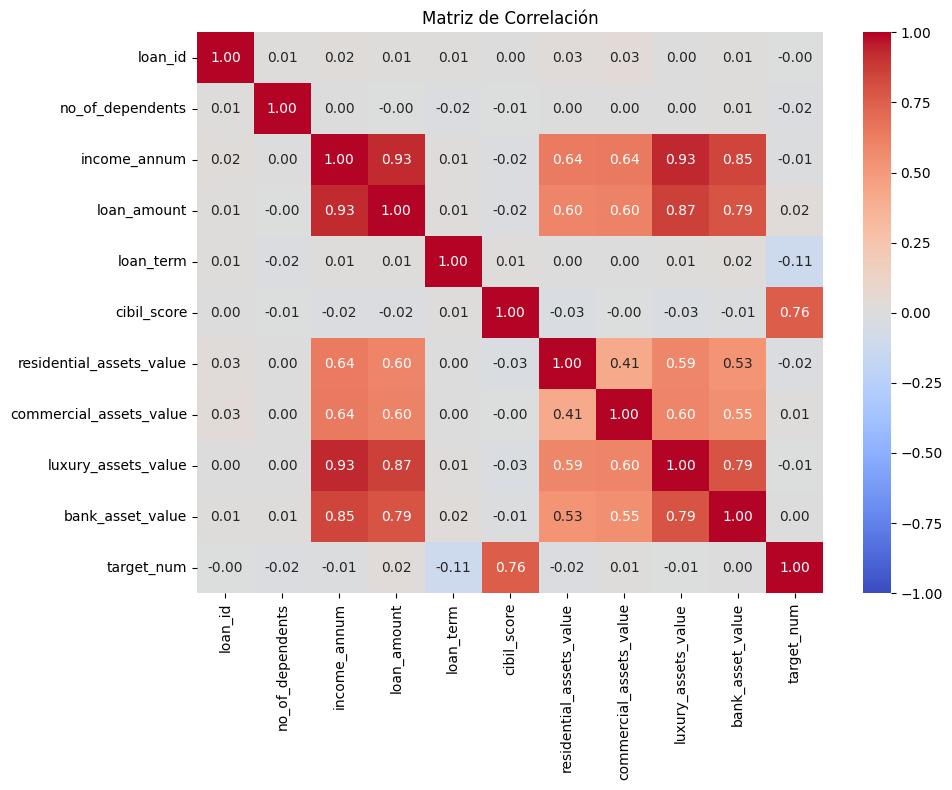

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# loan_status mapearla a 1/0 temporalmente para incluirla
if train_df['loan_status'].dtype == 'object':
    train_df['target_num'] = train_df['loan_status'].map({'Y': 1, 'N': 0, 'Approved': 1, 'Rejected': 0})

# Filtrar solo las variables numéricas
num_df = train_df.select_dtypes(include=['number'])

# Calcular correlación de Pearson
corr_matrix = num_df.corr()

# Generar el gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,       # Muestra el valor numérico
    fmt=".2f",        # 2 decimales para que sea legible
    cmap="coolwarm",  # Rojo para correlación positiva, azul para negativa
    vmin=-1, vmax=1   # Fija la escala estadística
)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

# Limpieza: borrar la columna temporal si la creaste
if 'target_num' in train_df.columns:
    train_df.drop(columns=['target_num'], inplace=True)

Boxplots de variables numéricas

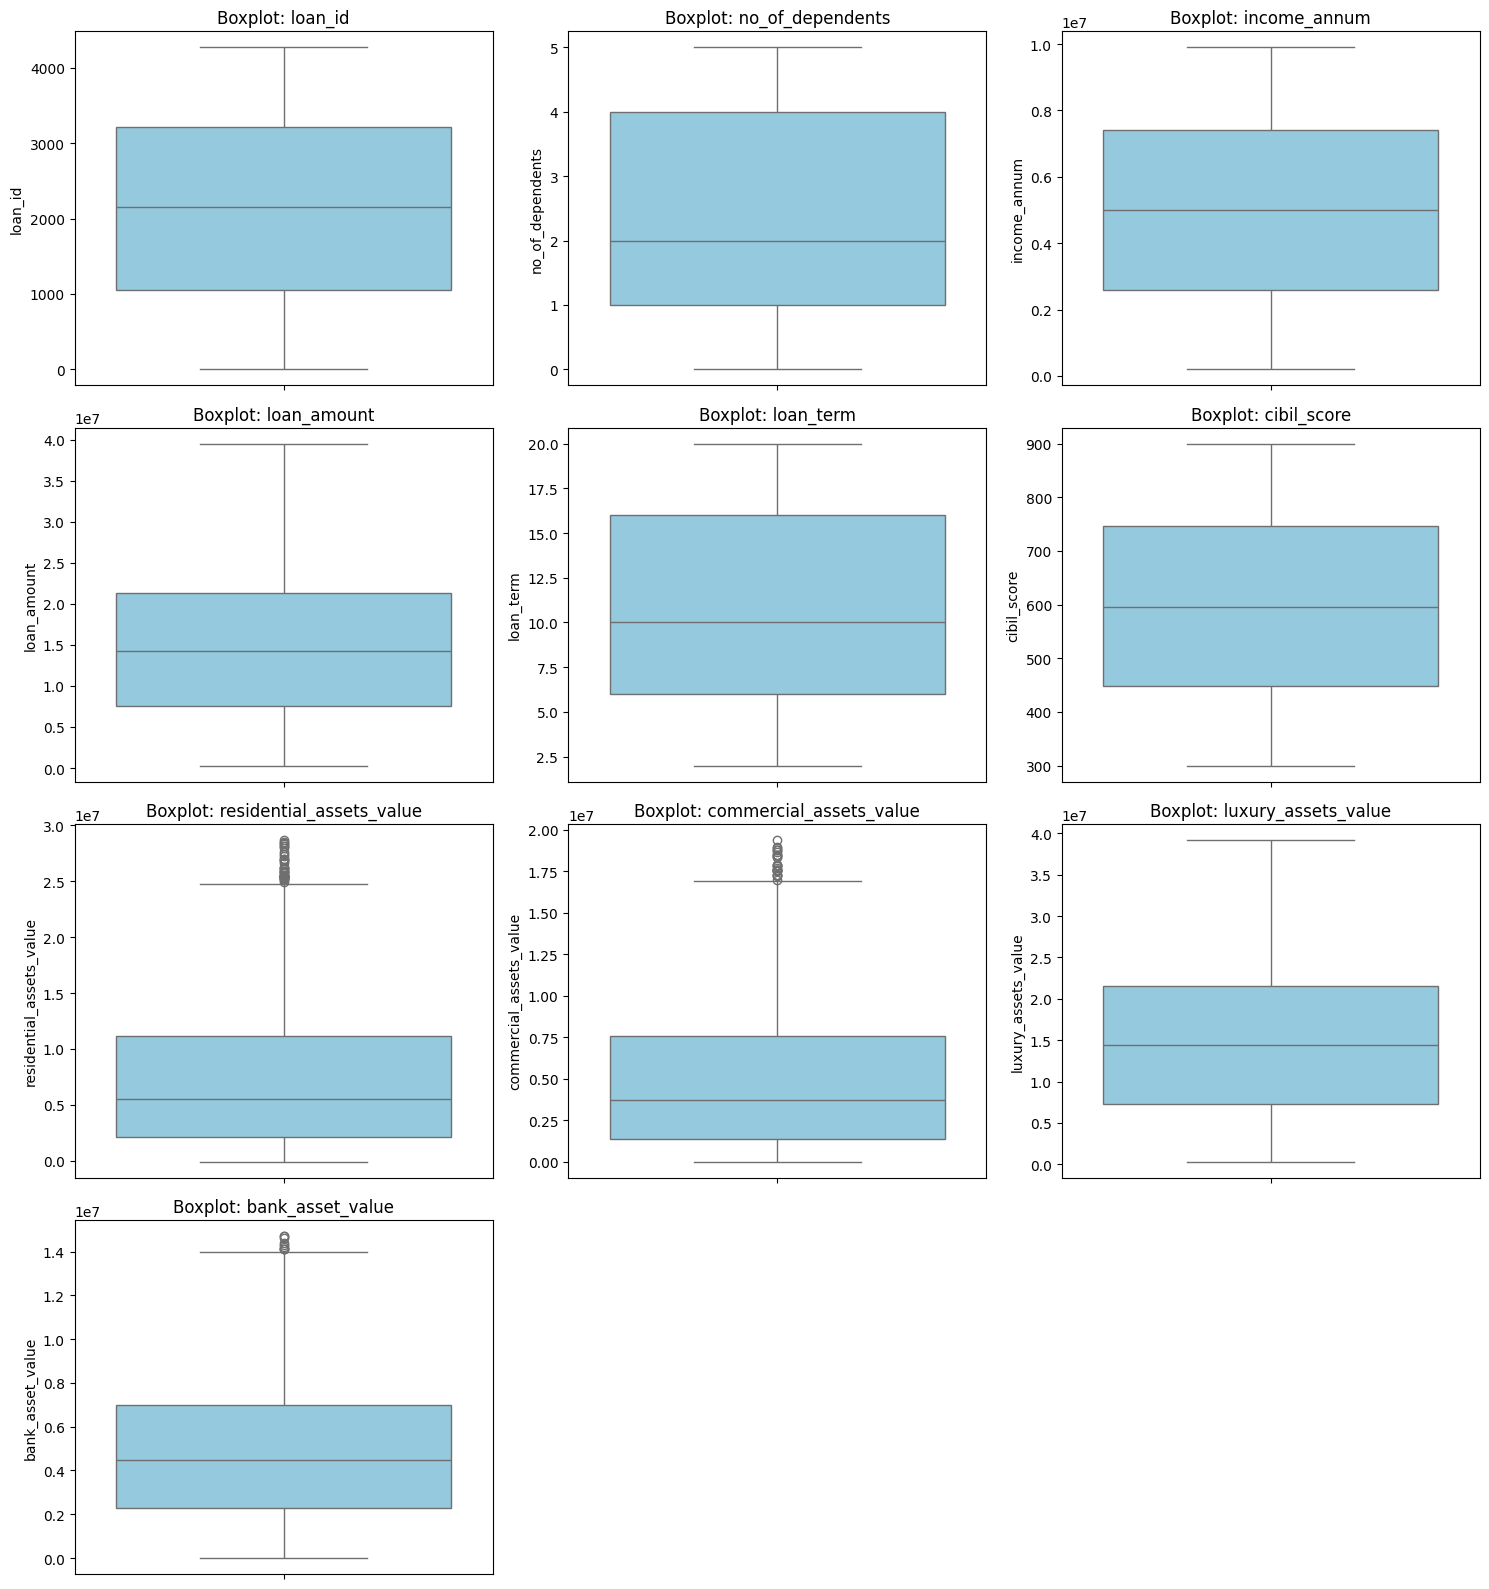

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Seleccionar columnas numéricas excluyendo IDs o flags artificiales
num_cols = [c for c in train_df.select_dtypes(include=['number']).columns if c != 'id']

# Configurar grilla dinámica de subplots
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))
for idx, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.boxplot(y=train_df[col], color="skyblue")
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()

plt.show()

Distribuciones y asimetrías

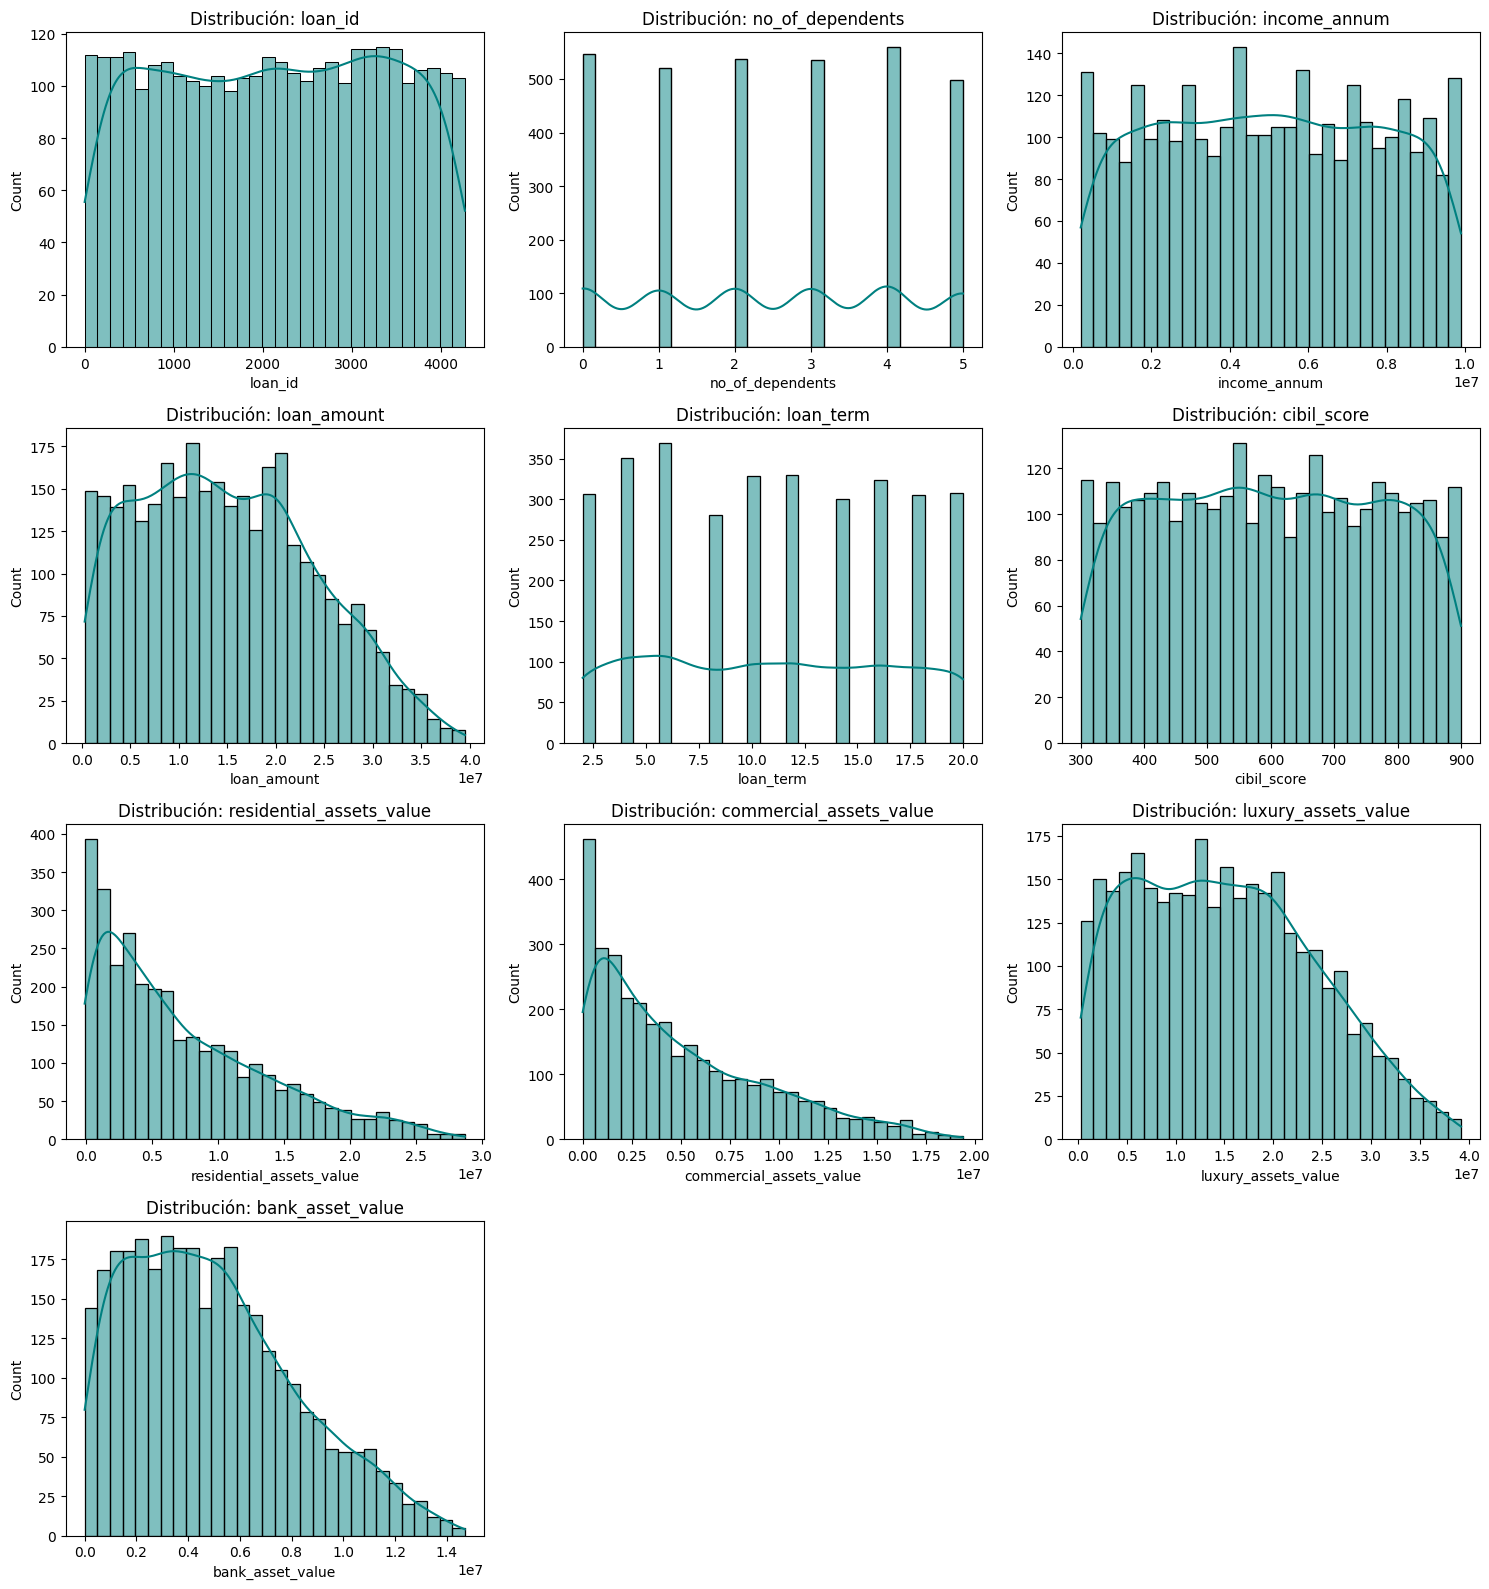

In [14]:
plt.figure(figsize=(15, n_rows * 4))
for idx, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.histplot(train_df[col], kde=True, color="teal", bins=30)
    plt.title(f"Distribución: {col}")
    plt.tight_layout()

plt.show()

Variables categóricas vs target

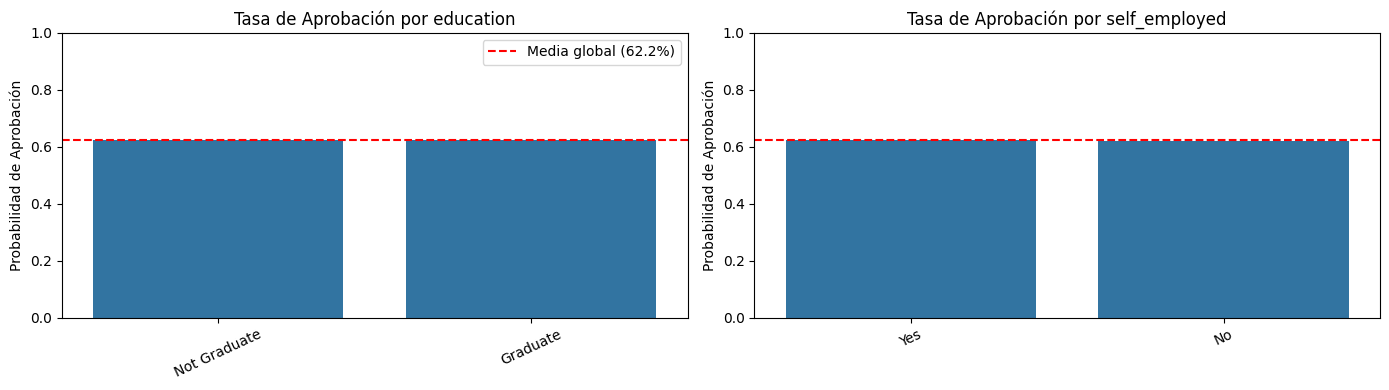

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Asegurar el target en formato binario (1: Aprobado, 0: Rechazado)
target_col = "loan_status"
train_df["target_bin"] = train_df[target_col].map(
    {"Y": 1, "N": 0, "Approved": 1, "Rejected": 0, 1: 1, 0: 0}
)
overall_approval_rate = train_df["target_bin"].mean()

# Filtrar columnas categóricas (excluyendo el target y posibles IDs)
cat_cols = [col for col in train_df.select_dtypes(include=["object", "category"]).columns if col not in [target_col, "id", "loan_id"]]

# Configurar grilla de subplots dinámica
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(14, n_rows * 4))

for idx, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, idx)
    
    # Calcular tasa de aprobación por categoría
    order = train_df.groupby(col)["target_bin"].mean().sort_values(ascending=False).index
    
    ax = sns.barplot(data=train_df, x=col, y="target_bin", order=order, errorbar=None)
    
    # Línea de referencia: promedio global de aprobación
    plt.axhline(overall_approval_rate, color="red", linestyle="--", label=f"Media global ({overall_approval_rate:.1%})")
    
    plt.title(f"Tasa de Aprobación por {col}")
    plt.ylabel("Probabilidad de Aprobación")
    plt.xlabel("")
    plt.ylim(0, 1)
    plt.xticks(rotation=25)
    if idx == 1:
        plt.legend()

plt.tight_layout()
plt.show()

# Limpieza de columna auxiliar
train_df.drop(columns=["target_bin"], inplace=True)

PCA

Varianza explicada PC1: 50.01%
Varianza explicada PC2: 11.43%
Varianza total acumulada (2 componentes): 61.44%


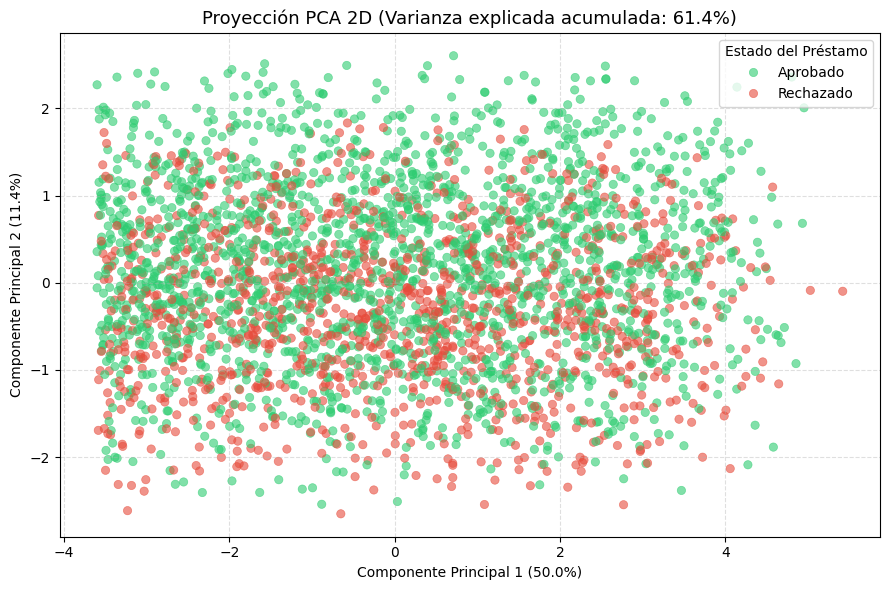

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleccionamos únicamente variables numéricas predictoras
status_map = {"Rejected": 0, "Approved": 1}
train_df["loan_status"] = train_df["loan_status"].astype(str).str.strip().map(status_map)

features_pca = [col for col in train_df.select_dtypes(include=["number"]).columns if col not in ["loan_status", "loan_id"]]

X_num = train_df[features_pca]
y = train_df["loan_status"]

# Estandarización obligatoria (media 0, varianza 1)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_num)

# Ajuste de PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Cálculo de varianza explicada
var_exp = pca.explained_variance_ratio_
var_cum = var_exp.sum() * 100

print(f"Varianza explicada PC1: {var_exp[0]:.2%}")
print(f"Varianza explicada PC2: {var_exp[1]:.2%}")
print(f"Varianza total acumulada (2 componentes): {var_cum:.2f}%")

# Visualización diagnóstica
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y.map({0: "Rechazado", 1: "Aprobado"}), 
    palette={"Rechazado": "#e74c3c", "Aprobado": "#2ecc71"}, 
    alpha=0.6,
    edgecolor=None
)

plt.title(f"Proyección PCA 2D (Varianza explicada acumulada: {var_cum:.1f}%)", fontsize=13)
plt.xlabel(f"Componente Principal 1 ({var_exp[0]:.1%})")
plt.ylabel(f"Componente Principal 2 ({var_exp[1]:.1%})")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Estado del Préstamo")
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

var_exp = pca_3d.explained_variance_ratio_
var_cum = var_exp.sum() * 100

# DataFrame con las 3 componentes y etiquetas descriptivas
pca_df_3d = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"], index=train_df.index)
pca_df_3d["Estado"] = y.map({0: "Rechazado", 1: "Aprobado"})

# Gráfico 3D interactivo con Plotly
fig = px.scatter_3d(
    pca_df_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Estado",
    color_discrete_map={"Rechazado": "#e74c3c", "Aprobado": "#2ecc71"},
    opacity=0.7,
    labels={
        "PC1": f"PC1 ({var_exp[0]:.1%})",
        "PC2": f"PC2 ({var_exp[1]:.1%})",
        "PC3": f"PC3 ({var_exp[2]:.1%})"
    },
    title=f"Proyección PCA 3D (Varianza explicada acumulada: {var_cum:.1f}%)"
)

# Ajuste de tamaño de puntos y aspecto del gráfico
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend_title_text="Estado del Préstamo"
)

fig.show()